# Localization with Acceleration

**Author:** Ella Ilan

**Date:** 2025-01-10 to 2025-01-17

**Relevant Links:**
- [Project DR0](https://docs.google.com/document/d/1tphoI5sxACXHOutE4Vw7ujA3iqmxGk2V70cow0bNCRc/edit?usp=sharing)



## Imports

Import any packages or dependencies for this project.
Uncomment or delete these lines as needed, and add other dependencies

In [3]:
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
from data_tools import query, FSGPDayLaps, TimeSeries
from datetime import datetime
import pytz
import data_tools
from scipy.integrate import cumulative_simpson
from scipy.signal import savgol_filter
import pandas as pd


## Data Acquisition

This code riffs off of Jonah's acceleration analysis. I tried working with 2024 data and our data tools, then realized we don't have acceleration sensors on the car from that time, so my query returned empty! This is 2025 data from our third lap.

In [116]:
client = query.DBClient()
#convert local to UTC even though the local time is wrong, stolen from Jonah
hour_fix = 7
#chose the best lap with no pitting from the third day of competition
#manually creating date time objects using lap times from spreadsheet
#13:34:32
lap_start_time = datetime(2025, 7, 5, 11 + hour_fix, 28, 36, tzinfo=pytz.UTC)
#13:40:43
lap_stop_time = datetime(2025, 7, 5, 11 + hour_fix, 34, 32, tzinfo=pytz.UTC)

print(lap_start_time)
print(lap_stop_time)

fields = ["Acceleration_X", "Acceleration_Y", "Acceleration_Z"]

# convert milli-Gs to m/s^2
G = 9.81
print("Collecting Lap Data")
raw_track_data = {}
for field in fields:
    print(f"    Queried {field}!")
    raw_track_data[field] = client.query_time_series(lap_start_time, lap_stop_time, field)/ 1000*G

#covert from km/hr to m/s
raw_track_data["MotorRotatingSpeed"] = client.query_time_series(lap_start_time, lap_stop_time, "MotorRotatingSpeed")/3.6
print(f"    Queried MotorRotatingSpeed!")


x, y, z, motor = TimeSeries.align(raw_track_data["Acceleration_X"], raw_track_data["Acceleration_Y"], raw_track_data["Acceleration_Z"], raw_track_data["MotorRotatingSpeed"])



2025-07-05 18:28:36+00:00
2025-07-05 18:34:32+00:00
    Queried Acceleration_X!
    Queried Acceleration_Y!
    Queried Acceleration_Z!
    Queried MotorRotatingSpeed!


## Plotting our expected Radius of Curvature

Using the Google Earth data, we can find expected radius of curvature. We can compare this to our sensor data to get further insights

In [5]:
#These are the coordinates of the track, stolen from Miguel

reverse_coords = [
    [ 37.0011529 , -86.36837867],
    [ 37.00122817, -86.3682181 ],
    [ 37.00133071, -86.36801267],
    [ 37.00143614, -86.36779264],
    [ 37.00152389, -86.3675912 ],
    [ 37.00160574, -86.36740819],
    [ 37.00167596, -86.36725066],
    [ 37.00175285, -86.36709064],
    [ 37.00183166, -86.36691875],
    [ 37.00192538, -86.36670617],
    [ 37.00200136, -86.36653034],
    [ 37.00208623, -86.36635086],
    [ 37.00215644, -86.36619701],
    [ 37.00222549, -86.36603626],
    [ 37.00229839, -86.3658645 ],
    [ 37.00237732, -86.36569622],
    [ 37.00245038, -86.36553914],
    [ 37.00252912, -86.36537128],
    [ 37.00259904, -86.36521818],
    [ 37.00266755, -86.36507091],
    [ 37.00274639, -86.36490341],
    [ 37.00283342, -86.36471029],
    [ 37.00291248, -86.36454704],
    [ 37.00298517, -86.36439075],
    [ 37.0030636 , -86.36423803],
    [ 37.00313338, -86.36408574],
    [ 37.00320937, -86.36393701],
    [ 37.00330797, -86.36377724],
    [ 37.00343811, -86.36368662],
    [ 37.00357758, -86.36365019],
    [ 37.00372489, -86.36360692],
    [ 37.00388711, -86.36356354],
    [ 37.00405472, -86.36352621],
    [ 37.00423763, -86.36348621],
    [ 37.00437129, -86.36338074],
    [ 37.00448184, -86.36323899],
    [ 37.00457515, -86.36307953],
    [ 37.0047012 , -86.36286956],
    [ 37.00486024, -86.36273924],
    [ 37.00505061, -86.36270756],
    [ 37.00527945, -86.36272947],
    [ 37.00548802, -86.36263566],
    [ 37.00565341, -86.36245496],
    [ 37.00573513, -86.3621647 ],
    [ 37.00568611, -86.36182869],
    [ 37.00548782, -86.36157939],
    [ 37.0052881 , -86.36149696],
    [ 37.00511652, -86.36149669],
    [ 37.0049746 , -86.36158761],
    [ 37.00485989, -86.3616726 ],
    [ 37.00469955, -86.3617696 ],
    [ 37.00451492, -86.36178471],
    [ 37.00435852, -86.36173599],
    [ 37.00419576, -86.36162316],
    [ 37.00409127, -86.36146652],
    [ 37.00404463, -86.3612301 ],
    [ 37.00407232, -86.36097832],
    [ 37.00415922, -86.36078578],
    [ 37.00426711, -86.36066944],
    [ 37.00439509, -86.36060407],
    [ 37.00452844, -86.36057503],
    [ 37.00466778, -86.36054604],
    [ 37.004833  , -86.36050987],
    [ 37.00499495, -86.36047743],
    [ 37.00514229, -86.36044484],
    [ 37.00524902, -86.36041601],
    [ 37.00541074, -86.36037856],
    [ 37.00558676, -86.36034575],
    [ 37.00578957, -86.36038183],
    [ 37.00596102, -86.36045445],
    [ 37.00607154, -86.36065091],
    [ 37.0061651 , -86.36090615],
    [ 37.00626234, -86.3611639 ],
    [ 37.00637312, -86.36147776],
    [ 37.00642557, -86.36179897],
    [ 37.00644459, -86.36216748],
    [ 37.00637929, -86.36250433],
    [ 37.00629836, -86.36273906],
    [ 37.00622229, -86.36291634],
    [ 37.00611158, -86.36309997],
    [ 37.00600738, -86.36323379],
    [ 37.00589169, -86.3633461 ],
    [ 37.00576471, -86.36344689],
    [ 37.00564905, -86.36353398],
    [ 37.00551878, -86.36359932],
    [ 37.00537978, -86.36365448],
    [ 37.00525188, -86.36370605],
    [ 37.0051236 , -86.36376501],
    [ 37.00497727, -86.36382802],
    [ 37.00484855, -86.36391978],
    [ 37.00471266, -86.36403361],
    [ 37.0045783 , -86.36422396],
    [ 37.00447907, -86.36439954],
    [ 37.00435695, -86.36453807],
    [ 37.00424813, -86.36465022],
    [ 37.00411061, -86.36480228],
    [ 37.00397977, -86.36492984],
    [ 37.0038682 , -86.36504946],
    [ 37.00376295, -86.36516126],
    [ 37.00365436, -86.36527329],
    [ 37.00354759, -86.36539144],
    [ 37.00341675, -86.36552332],
    [ 37.00329206, -86.3656715 ],
    [ 37.00316095, -86.36581567],
    [ 37.00303256, -86.36594441],
    [ 37.00291203, -86.36607157],
    [ 37.00278014, -86.36622802],
    [ 37.00269333, -86.36641303],
    [ 37.00260606, -86.36659437],
    [ 37.00252845, -86.36675984],
    [ 37.00243487, -86.36695271],
    [ 37.00234795, -86.36716654],
    [ 37.00226102, -86.36735999],
    [ 37.00218046, -86.36754144],
    [ 37.00210026, -86.36771854],
    [ 37.00202358, -86.36787901],
    [ 37.00194406, -86.36806693],
    [ 37.00185835, -86.36825428],
    [ 37.00177578, -86.36843604],
    [ 37.00169902, -86.36860048],
    [ 37.0016732 , -86.3687928 ],
    [ 37.001679  , -86.3689974 ],
    [ 37.00168488, -86.36919051],
    [ 37.00169122, -86.36938766],
    [ 37.00169469, -86.3695562 ],
    [ 37.00170118, -86.36974238],
    [ 37.00171055, -86.36993991],
    [ 37.00167198, -86.37010864],
    [ 37.00158558, -86.37021273],
    [ 37.00148934, -86.37030898],
    [ 37.00139295, -86.37041757],
    [ 37.00129011, -86.37051816],
    [ 37.00120286, -86.37061913],
    [ 37.00112253, -86.37073184],
    [ 37.00106144, -86.37085264],
    [ 37.00099678, -86.37100197],
    [ 37.00092255, -86.37116696],
    [ 37.00083249, -86.37137665],
    [ 37.00073506, -86.37159438],
    [ 37.00065426, -86.37177611],
    [ 37.00057398, -86.37196168],
    [ 37.00060097, -86.37214635],
    [ 37.00074272, -86.37221467],
    [ 37.0009059 , -86.37222018],
    [ 37.00107657, -86.37218846],
    [ 37.00122503, -86.37211976],
    [ 37.00133803, -86.37204677],
    [ 37.00145467, -86.37192099],
    [ 37.00156457, -86.37178347],
    [ 37.00167114, -86.37162599],
    [ 37.00176434, -86.37145299],
    [ 37.00183833, -86.37126821],
    [ 37.00188646, -86.37112396],
    [ 37.0019441 , -86.37095574],
    [ 37.00197296, -86.370787  ],
    [ 37.00202945, -86.37067751],
    [ 37.00209668, -86.37048098],
    [ 37.00218305, -86.37031655],
    [ 37.00228558, -86.37016005],
    [ 37.00238818, -86.37002764],
    [ 37.00249377, -86.36991909],
    [ 37.00259639, -86.36983868],
    [ 37.00270864, -86.36976266],
    [ 37.00281411, -86.3697033 ],
    [ 37.00292264, -86.36964769],
    [ 37.00303847, -86.369599  ],
    [ 37.00316942, -86.36952703],
    [ 37.00332578, -86.36939126],
    [ 37.00342743, -86.36921198],
    [ 37.00346211, -86.36901195],
    [ 37.00343231, -86.36879509],
    [ 37.00336736, -86.36861758],
    [ 37.00327983, -86.36847602],
    [ 37.00316589, -86.36828932],
    [ 37.00305696, -86.36810259],
    [ 37.00296937, -86.36793662],
    [ 37.00293802, -86.36773416],
    [ 37.00295792, -86.36753614],
    [ 37.00301643, -86.36739089],
    [ 37.00307192, -86.36724611],
    [ 37.00312788, -86.36711056],
    [ 37.00320856, -86.36698638],
    [ 37.00331523, -86.36684361],
    [ 37.00340519, -86.36672019],
    [ 37.00350264, -86.36658791],
    [ 37.00361135, -86.36649982],
    [ 37.00374245, -86.36645177],
    [ 37.00387034, -86.3664758 ],
    [ 37.00395668, -86.36655587],
    [ 37.00402368, -86.36670753],
    [ 37.00407807, -86.36686779],
    [ 37.00412607, -86.36701603],
    [ 37.00418686, -86.36718831],
    [ 37.00427315, -86.36742386],
    [ 37.00436296, -86.3676927 ],
    [ 37.00442144, -86.36790543],
    [ 37.00445858, -86.36815496],
    [ 37.00447715, -86.36847342],
    [ 37.00444541, -86.36882644],
    [ 37.00434238, -86.36911386],
    [ 37.00425654, -86.36927291],
    [ 37.00418289, -86.36939303],
    [ 37.00410293, -86.36950912],
    [ 37.00399731, -86.36962489],
    [ 37.00390147, -86.36973254],
    [ 37.00379293, -86.36984054],
    [ 37.00369701, -86.36994104],
    [ 37.00359474, -86.37004514],
    [ 37.0034838 , -86.3701598 ],
    [ 37.00338477, -86.37024376],
    [ 37.00327609, -86.37032788],
    [ 37.00318982, -86.37040789],
    [ 37.00306205, -86.37049992],
    [ 37.00294389, -86.37059192],
    [ 37.00283177, -86.37070006],
    [ 37.00272312, -86.37083897],
    [ 37.00264003, -86.37094293],
    [ 37.00255683, -86.37103895],
    [ 37.00249914, -86.37115127],
    [ 37.00243497, -86.37126771],
    [ 37.00236746, -86.3713964 ],
    [ 37.00230001, -86.37152106],
    [ 37.00223561, -86.37164596],
    [ 37.00217132, -86.37175865],
    [ 37.0021135 , -86.37187932],
    [ 37.00204601, -86.37200003],
    [ 37.00196791, -86.37211434],
    [ 37.00188761, -86.3722312 ],
    [ 37.00180726, -86.37233202],
    [ 37.00173651, -86.37241676],
    [ 37.00165284, -86.37250555],
    [ 37.00155067, -86.3726109 ],
    [ 37.00144762, -86.37271211],
    [ 37.00136704, -86.37279282],
    [ 37.00126713, -86.37288565],
    [ 37.00115123, -86.37299929],
    [ 37.00103518, -86.37310829],
    [ 37.0009191 , -86.37321738],
    [ 37.00082561, -86.37329809],
    [ 37.00072863, -86.37339546],
    [ 37.00061364, -86.37350099],
    [ 37.00051698, -86.37360214],
    [ 37.00042667, -86.37368311],
    [ 37.00032338, -86.37378434],
    [ 37.00022342, -86.37387665],
    [ 37.00012018, -86.3739737 ],
    [ 37.00002051, -86.37405916],
    [ 36.99991404, -86.37415222],
    [ 36.99981076, -86.37423248],
    [ 36.99970432, -86.37430523],
    [ 36.99958169, -86.37432571],
    [ 36.99946928, -86.37430399],
    [ 36.99934964, -86.37428072],
    [ 36.99922365, -86.37425686],
    [ 36.99908793, -86.37422888],
    [ 36.99899069, -86.37413638],
    [ 36.99896465, -86.37397888],
    [ 36.9989808 , -86.37380904],
    [ 36.99900664, -86.37362303],
    [ 36.99904589, -86.37342887],
    [ 36.9990885 , -86.37323096],
    [ 36.99912743, -86.3730292 ],
    [ 36.99916641, -86.37284378],
    [ 36.99921127, -86.37261758],
    [ 36.99924349, -86.37245211],
    [ 36.99932082, -86.37230251],
    [ 36.99932082, -86.37230251],
    [ 36.99940337, -86.37214797],
    [ 36.99948814, -86.37199725],
    [ 36.99958754, -86.37189043],
    [ 36.99970528, -86.37178738],
    [ 36.99982625, -86.37169183],
    [ 36.99997073, -86.37159181],
    [ 37.00011471, -86.3714889 ],
    [ 37.00027357, -86.37138907],
    [ 37.0003852 , -86.37123775],
    [ 37.00042033, -86.37099884],
    [ 37.00038811, -86.3707825 ],
    [ 37.00031195, -86.37062837],
    [ 37.00026491, -86.37041498],
    [ 37.00030254, -86.37020247],
    [ 37.00038472, -86.3700261 ],
    [ 37.0004699 , -86.36984594],
    [ 37.00056383, -86.36964375],
    [ 37.00064015, -86.3694857 ],
    [ 37.00070993, -86.36934481],
    [ 37.0008098 , -86.36912411],
    [ 37.00090662, -86.36891836],
    [ 37.00098578, -86.36874579],
    [ 37.00107373, -86.36854755]
  ]

coords = reverse_coords[::-1] # coordinates in the correct order; starting coordinate goes first

Using some math, we can use some given number of nearest points to calculate curvature given points and their neighbours.

In [6]:
import math

def calculate_circular_track_curvature(coords, step=1):
    """
    Calculates curvature for a CLOSED LOOP (circular) race track.

    :param coords: List of tuples [(lat, lon), ...] assumed to be in order.
    :param step: The smoothing stride (1=sensitive, 5=smooth).
    :return: List of radii in meters.
    """

    if not coords:
        return []

    # 1. Convert Lat/Lon to Local X/Y (Meters)
    # We use the first point as the reference center for projection
    center_lat = coords[0][0]

    # Calculate conversion factors based on the track's latitude
    meters_per_deg_lat = 111132.954 - 559.822 * math.cos(2 * math.radians(center_lat))
    meters_per_deg_lon = 111412.84 * math.cos(math.radians(center_lat))

    xy_points = []
    for lat, lon in coords:
        y = lat * meters_per_deg_lat
        x = lon * meters_per_deg_lon
        xy_points.append((x, y))

    radii = []
    n = len(xy_points)

    # 2. Calculate Radius with Wrap-Around Indexing
    for i in range(n):
        # Use modulo (%) to wrap around the start/finish line
        # If i=0 and step=1, the "previous" point becomes the last point in the list
        p1 = xy_points[(i - step) % n]
        p2 = xy_points[i]
        p3 = xy_points[(i + step) % n]

        # Calculate side lengths (Euclidean distance)
        a = math.dist(p1, p2)
        b = math.dist(p2, p3)
        c = math.dist(p3, p1)

        # Shoelace formula for Area of the triangle
        area = 0.5 * abs(p1[0]*(p2[1] - p3[1]) +
                         p2[0]*(p3[1] - p1[1]) +
                         p3[0]*(p1[1] - p2[1]))

        # Calculate Radius (R = abc / 4A)
        if area < 1e-6:
            radii.append(0) # Straight line
        else:
            R = (a * b * c) / (4 * area)
            #if R > 10000:
              #  R = 0
            radii.append(1/R)


    return radii

This function gives us a list of radii of curvature.

In [7]:
radius_of_curvature = calculate_circular_track_curvature(coords, step=4)
print(radius_of_curvature)

[0.00027635629037407776, 4.128098655599364e-05, 0.00016997315981238706, 0.0001312498062768574, 0.00025747253273897323, 4.8160807792308406e-05, 0.001088670492468534, 0.003875251441807838, 0.007775839459387573, 0.009567680600742071, 0.008235422949598014, 0.002629548829497893, 0.006585179519230182, 0.012520885152587658, 0.014923015751578046, 0.013629620053821397, 0.008168401945784944, 0.0032082880796133963, 0.001993242507144598, 0.004563653831193995, 0.005905093647194941, 0.006787986642280979, 0.0070387075589848185, 0.007119242992791627, 0.006187854436374556, 0.005754561541904306, 0.0036620887650737855, 0.0014907614314290502, 0.0012926998581351363, 0.0005684944742989738, 0.0022046058602545452, 0.006544255639972267, 0.013386063382420191, 0.01915749431162886, 0.02164896682024677, 0.021237223041439025, 0.01703711080132082, 0.012448194658823894, 0.010046931185026342, 0.010940914917225951, 0.011780868632546165, 0.009629111340047753, 0.0066330762853598286, 0.0033562085788226537, 0.0013700415235

We can plot this on a graph. We expect to see the corners and straights colored differently!

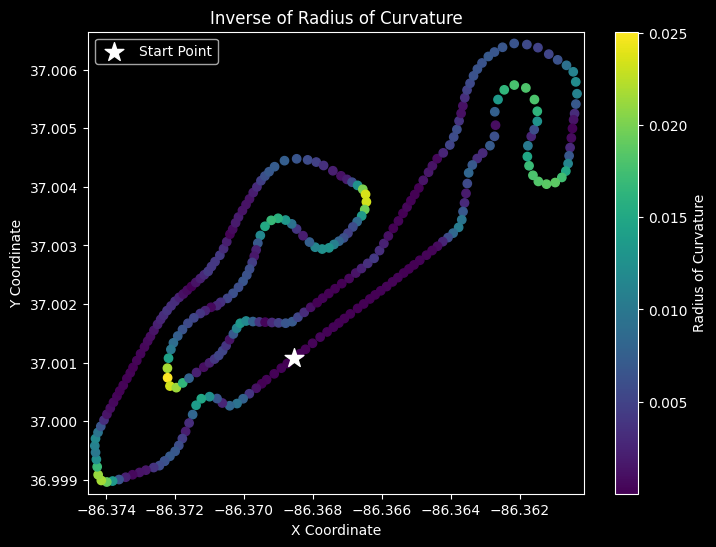

In [8]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

# Separating the coordinates into x and y components
x_coords = [coord[1] for coord in coords]
y_coords = [coord[0] for coord in coords]

# Create an array of points from the coordinates
points = np.array([x_coords, y_coords]).T.reshape(-1, 1, 2)

# Create a plot
plt.figure(figsize=(8, 6))
plt.scatter(x_coords, y_coords, c= radius_of_curvature)
plt.gca().get_yaxis().get_major_formatter().set_useOffset(False)

# Add a color bar to show the velocity scale
plt.colorbar( label='Radius of Curvature')

# Add labels, grid, and title
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title("Inverse of Radius of Curvature")



# Adjust the axis limits to fit the track
plt.xlim(min(x_coords) - 0.0002, max(x_coords) + 0.0002)
plt.ylim(min(y_coords) - 0.0002, max(y_coords) + 0.0002)

# Optionally, highlight the starting point
plt.scatter(x_coords[0], y_coords[0], color='white', s=200, marker='*', label='Start Point')

# Add a legend and show the plot
plt.legend()
plt.show()

## Working with our acceleration data


We want to generate the same graph using sensor data to find radii instead of GPS points. Sanity check to see our data query is working!

In an earlier project, Jonah identified that Acceleration_Y was the centripedal acceleration. See his acceleratiom_analysis project for more details

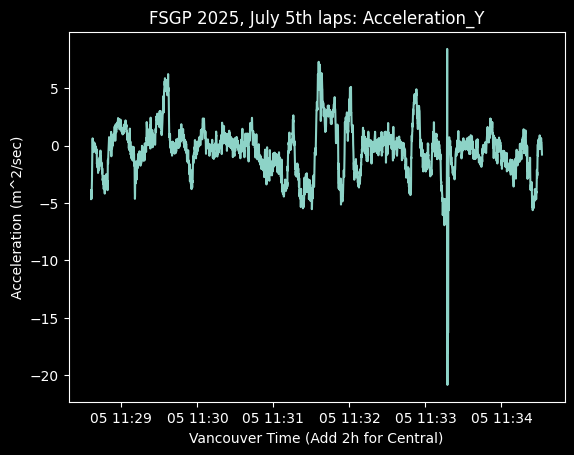

In [117]:
plt.plot(raw_track_data["Acceleration_Y"].datetime_x_axis, raw_track_data["Acceleration_Y"])
plt.ylabel("Acceleration (m^2/sec)")
plt.xlabel("Vancouver Time (Add 2h for Central)")
plt.title("FSGP 2025, July 5th laps: Acceleration_Y")
plt.show()

The data from the censor is really noisy but generally sensical. The following function is a botched attempt at finding the radii using data queried from the database. Later, I decide it's better to do this using just Acceleration_Y as centrepidal force.

In [118]:
def calculate_radius_from_scaled_velocity(v_raw, ax_raw, ay_raw, dt):
    # 1. Force conversion to standard numpy arrays immediately
    # This bypasses the custom TimeSeries __getitem__ logic
    v_scaled = np.asarray(v_raw)
    ax = np.asarray(ax_raw)
    ay = np.asarray(ay_raw)

    # 3. Calculate Tangential Acceleration (dv/dt)
    # Using v directly (assuming it is already m/s based on your previous 'scaled' comment)
    # If it's still in RPM, multiply by (2 * np.pi / 60) * radius here
    a_tangential = np.gradient(v_raw, dt)

    # 4. Get Total Acceleration Magnitude squared
    a_total_sq = ax**2 + ay**2

    # 5. Extract the Centripetal (Turning) Acceleration
    # a_centripetal^2 = a_total^2 - a_tangential^2
    a_centripetal_sq = np.clip(a_total_sq - a_tangential**2, 0, None)
    a_centripetal = np.sqrt(a_centripetal_sq)

    # 6. Calculate Radius (R = v^2 / a_centripetal)
    radius = np.full_like(v_raw, np.inf)

    # Avoid division by zero
    mask = (a_centripetal > 1e-4) & (v_raw > 0.1)
    radius[mask] = (v_raw[mask]**2) / a_centripetal[mask]

    return radius

In [119]:
calculated_radius = calculate_radius_from_scaled_velocity(motor, x, y, 0.1)

radius_with_xy = 1/calculated_radius


In [120]:
print(radius_with_xy)


[0.07897489 0.07379561 0.07756482 ... 0.07881478 0.07677762 0.0713407 ]


The following function is much better at calculating the radius and generally seems to use the sensor data more correctly.

In [121]:
def calculate_radius_direct(v, a_centripetal):
    """
    Calculates radius of curvature directly from velocity and centripetal acceleration.

    Parameters:
    -----------
    v : np.ndarray
        Linear velocity (speed) in m/s.
    a_centripetal : np.ndarray
        The lateral/centripetal component of acceleration in m/s^2.
    """
    # Initialize with infinity (represents driving straight)
    radius = np.full_like(v, np.inf, dtype=float)

    # Create a mask to avoid DivisionByZero or invalid math
    # 1. Must be moving (v > 0)
    # 2. Must be turning (a_c > 0)
    mask = (np.abs(a_centripetal) > 1e-5) & (np.abs(v) > 1e-5)

    # R = v^2 / a_c
    radius[mask] = (v[mask]**2) / np.abs(a_centripetal[mask])

    return radius

In [122]:
centri_radius= calculate_radius_direct(motor, y)
calculate_radius_yonly = 1/centri_radius
print(calculate_radius_yonly)
len(calculate_radius_yonly)

[0.03483339 0.02870119 0.03252474 ... 0.00175272 0.00266378 0.0060383 ]


3559

In [123]:
print(radius_of_curvature)

[0.00027635629037407776, 4.128098655599364e-05, 0.00016997315981238706, 0.0001312498062768574, 0.00025747253273897323, 4.8160807792308406e-05, 0.001088670492468534, 0.003875251441807838, 0.007775839459387573, 0.009567680600742071, 0.008235422949598014, 0.002629548829497893, 0.006585179519230182, 0.012520885152587658, 0.014923015751578046, 0.013629620053821397, 0.008168401945784944, 0.0032082880796133963, 0.001993242507144598, 0.004563653831193995, 0.005905093647194941, 0.006787986642280979, 0.0070387075589848185, 0.007119242992791627, 0.006187854436374556, 0.005754561541904306, 0.0036620887650737855, 0.0014907614314290502, 0.0012926998581351363, 0.0005684944742989738, 0.0022046058602545452, 0.006544255639972267, 0.013386063382420191, 0.01915749431162886, 0.02164896682024677, 0.021237223041439025, 0.01703711080132082, 0.012448194658823894, 0.010046931185026342, 0.010940914917225951, 0.011780868632546165, 0.009629111340047753, 0.0066330762853598286, 0.0033562085788226537, 0.0013700415235

We're going to import GIS packages to work with our coordinates and find the length of the lap. Borrowed this method from Miguel.

In [124]:
from physics.environment.gis.gis import GIS
from physics.environment.gis.gis import calculate_path_distances

# Defining dictionary "route_data"

route_data = {
    "path" : np.array(coords),
    "elevations" : np.zeros(len(coords)),
    "time_zones" : np.zeros(len(coords)),
    "num_unique_coords" : (len(coords) - 1) }

# Creating GIS object

starting_coords = [37.00107373, -86.36854755]

gis = GIS(route_data, starting_coords, current_coord = starting_coords)

lap_length = np.cumsum(calculate_path_distances(gis.path[:gis.num_unique_coords]))[-1] # TOTAL LAP LENGTH

We find the distance we have travelled so far, and make a list of distances travelled as time goes on.


In [125]:

from scipy import integrate

def distance_so_far(v_ts, start_time, end_time, dt=0.1):
    return v_ts*v_ts.period


In [126]:
distance_list = distance_so_far(motor, lap_start_time, lap_stop_time, dt=0.1)
np.sum(distance_list)

TimeSeries(5271.70036253)

In [127]:
print(lap_length)

5033.624134716312


We give our list of distances to the return_coords function, which returns the nearest Google Earth coordinate for easy graphing.

In [128]:
def return_coords(distances:list):
    total_lap_distance = sum(distances)
    total_track_length = 5033.62413471853
    index = gis._python_calculate_closest_gis_indices(distances*(total_track_length/total_lap_distance), gis.get_path_distances())
    return route_data.get("path")[index], index

In [129]:
coords_calc, index = return_coords(distance_list)

len(coords_calc)
len(calculate_radius_yonly)


Calculating closest GIS indices: 100%|██████████| 3559/3559 [00:00<00:00, 937541.01it/s]


3559

In [130]:
mean_radius_per_index = (
    pd.Series(calculate_radius_yonly)
      .groupby(index)
      .mean()
)
print(mean_radius_per_index)

0      0.018366
1      0.001272
2      0.002090
3      0.010024
4      0.006829
         ...   
284    0.011722
285    0.024066
286    0.037663
287    0.032725
288    0.003307
Length: 288, dtype: float64


Let's try and generate the same graph from earlier but using the censor data instead of points on the Google Earth map.


In [131]:
new_coords = [(round(x, 5), round(y, 5)) for x, y in coords]
unique_coords = list(dict.fromkeys(new_coords))
len(unique_coords)


289

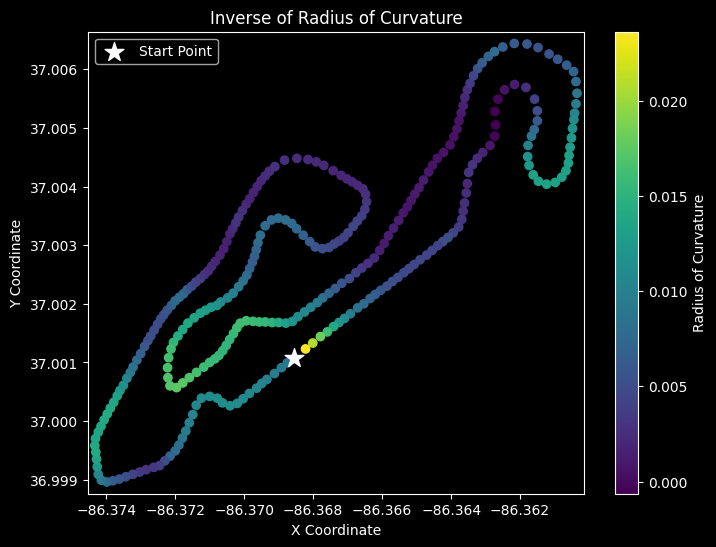

In [132]:
# Separating the coordinates into x and y components
x_coords2 = [coord[1] for coord in unique_coords]
y_coords2 = [coord[0] for coord in unique_coords]

# 🔧 remove the last point
x_coords2 = x_coords2[:-1]
y_coords2 = y_coords2[:-1]

# Create an array of points from the coordinates
points = np.array([x_coords2, y_coords2]).T.reshape(-1, 1, 2)

# Create a plot
radius_colors = radius_with_xy
plt.figure(figsize=(8, 6))
plt.scatter(x_coords2, y_coords2, c=savgol_filter(mean_radius_per_index, 45, 4))
plt.gca().get_yaxis().get_major_formatter().set_useOffset(False)

# Add a color bar to show the velocity scale
plt.colorbar(label='Radius of Curvature')

# Add labels, grid, and title
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title("Inverse of Radius of Curvature")

# Adjust the axis limits to fit the track
plt.xlim(min(x_coords2) - 0.0002, max(x_coords2) + 0.0002)
plt.ylim(min(y_coords2) - 0.0002, max(y_coords2) + 0.0002)

# Optionally, highlight the starting point
plt.scatter(x_coords2[0], y_coords2[0], color='white', s=200, marker='*', label='Start Point')

# Add a legend and show the plot
plt.legend()
plt.show()


Here, we compare the results in a line graph, to see major differences.

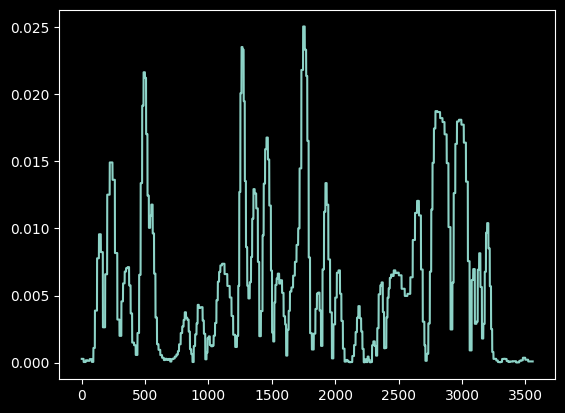

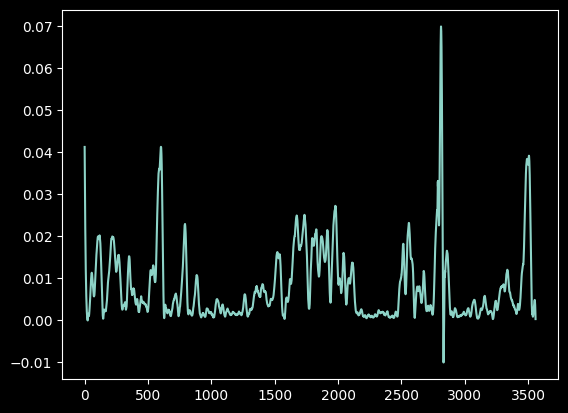

In [133]:
predicted_radius = np.array(radius_of_curvature)[index]
measured_radius = calculate_radius_yonly

plt.plot(predicted_radius)
plt.show()

plt.plot(savgol_filter(measured_radius, 50, 4))
plt.show()




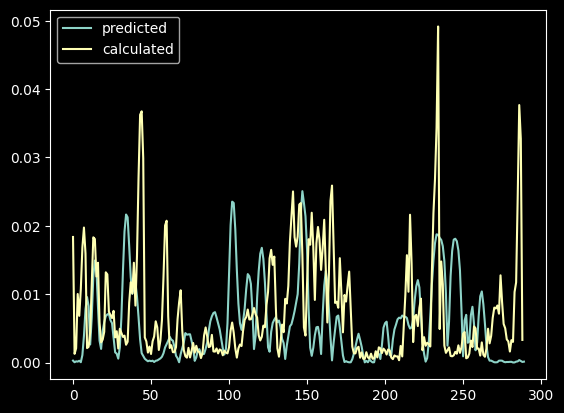

In [134]:
plt.plot(radius_of_curvature, label = "predicted")
plt.plot(mean_radius_per_index, label = "calculated")
plt.legend()
plt.show()